In [16]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

S = $Tr[\rho_A log \rho_A]$

$\rho_A = Tr_{A}[\rho_{full}]$

$\rho_{full} = \ket{\psi(t)}\bra{\psi(t)}$

In [17]:
def embed_scar_state_to_full(state, basisList, N):
    vec_constrained = state.full().flatten()
    vec_full = np.zeros(2**N, dtype=complex)

    for i, bitstr in enumerate(basisList):
        full_index = int(bitstr, 2)
        vec_full[full_index] = vec_constrained[i]

    return qt.Qobj(vec_full, dims=[[2]*N, [1]*N])

In [18]:
tlist = np.linspace(0, 500, 1000)
N = 4
dz, dy, dx = 0, 0, 0

qubitEntangle = []
for _ in range(25):
    H0, H1, eigenvalues, eigenstates = get_qubit_ham(N, ham_disorder=[dz, dy, dx], random_seed=True)
    args = {"A": 0.1, "omega": 1.0}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist)

    temp = []
    for state in psi_t.states:
        psi_full = state
        rho_A = psi_full.ptrace(list(range(N//2)))
        temp.append(qt.entropy_vn(rho_A))
    qubitEntangle.append(temp)

wd = 0.6365091993031
scarEntangle = []
for _ in range(25):
    H0, H1, eigenvalues, eigenstates, psi0, basisList  = get_scar_ham(N, ham_disorder=[dz, dy, dx], random_seed=True)
    args = {"A": 0.1, "omega": wd}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist)

    temp = []
    for state in psi_t.states:
        psi_full = embed_scar_state_to_full(state, basisList, N)
        rho_A = psi_full.ptrace(list(range(N//2)))
        temp.append(qt.entropy_vn(rho_A))
    scarEntangle.append(temp)

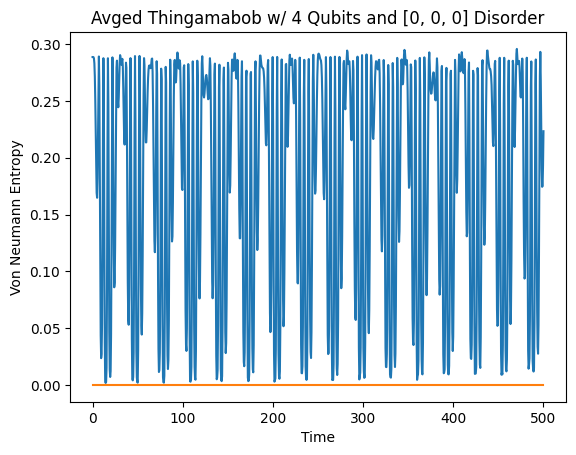

In [19]:
scarEntangle = np.array(scarEntangle)
plotScar = np.mean(scarEntangle, axis=0)

qubitEntangle = np.array(qubitEntangle)
plotQubit = np.mean(qubitEntangle, axis=0)

plt.plot(tlist, plotScar)
plt.plot(tlist, plotQubit)
plt.title(f"Avged Thingamabob w/ {N} Qubits and {[dz, dy, dx]} Disorder")
plt.ylabel("Von Neumann Entropy")
plt.xlabel("Time")
plt.show()